In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/workspaces/Top-Radar/creditcard.csv')

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
print(f"Fraudes: {df['Class'].sum():,}")
print(f"% de fraude: {df['Class'].mean()*100:.2f}%")

Linhas: 284,807
Colunas: 31
Fraudes: 492
% de fraude: 0.17%


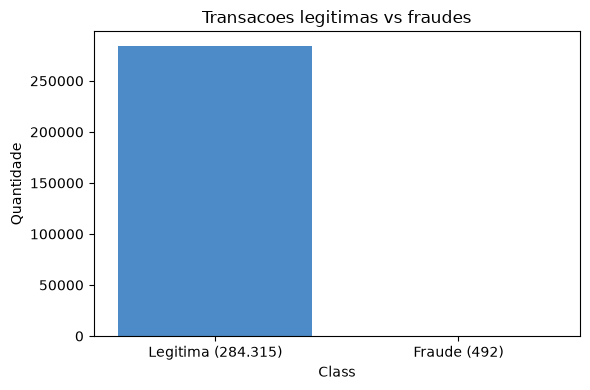

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, hue='Class',
              palette=['#378ADD', '#E24B4A'], legend=False)
plt.title('Transacoes legitimas vs fraudes')
plt.xticks([0, 1], ['Legitima (284.315)', 'Fraude (492)'])
plt.ylabel('Quantidade')
plt.tight_layout()
plt.savefig('/workspaces/Top-Radar/grafico1.png', dpi=150)
plt.show()

Fraudes   - media: $122.21 | max: $2125.87
Legitimas - media: $88.29 | max: $25691.16


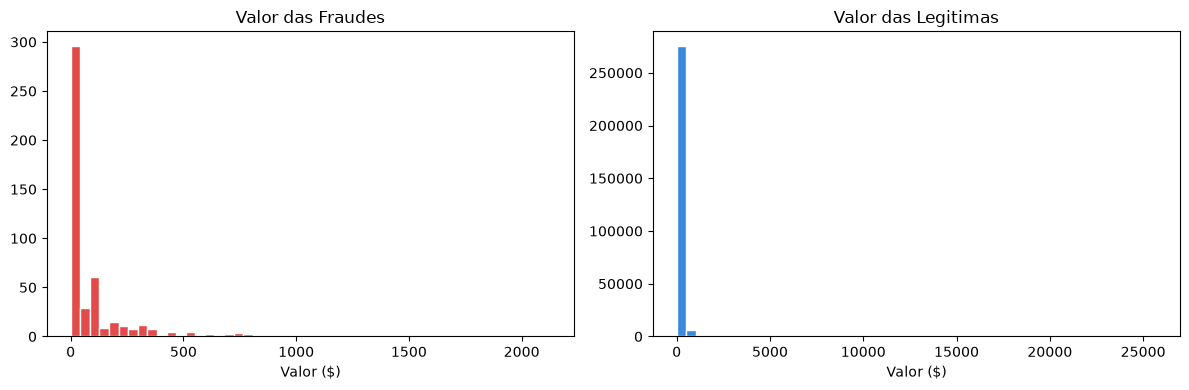

In [3]:
fraudes   = df[df['Class'] == 1]['Amount']
legitimas = df[df['Class'] == 0]['Amount']

print(f"Fraudes   - media: ${fraudes.mean():.2f} | max: ${fraudes.max():.2f}")
print(f"Legitimas - media: ${legitimas.mean():.2f} | max: ${legitimas.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fraudes,   bins=50, color='#E24B4A', edgecolor='white')
axes[0].set_title('Valor das Fraudes')
axes[0].set_xlabel('Valor ($)')
axes[1].hist(legitimas, bins=50, color='#378ADD', edgecolor='white')
axes[1].set_title('Valor das Legitimas')
axes[1].set_xlabel('Valor ($)')
plt.tight_layout()
plt.savefig('/workspaces/Top-Radar/grafico2.png', dpi=150)
plt.show()

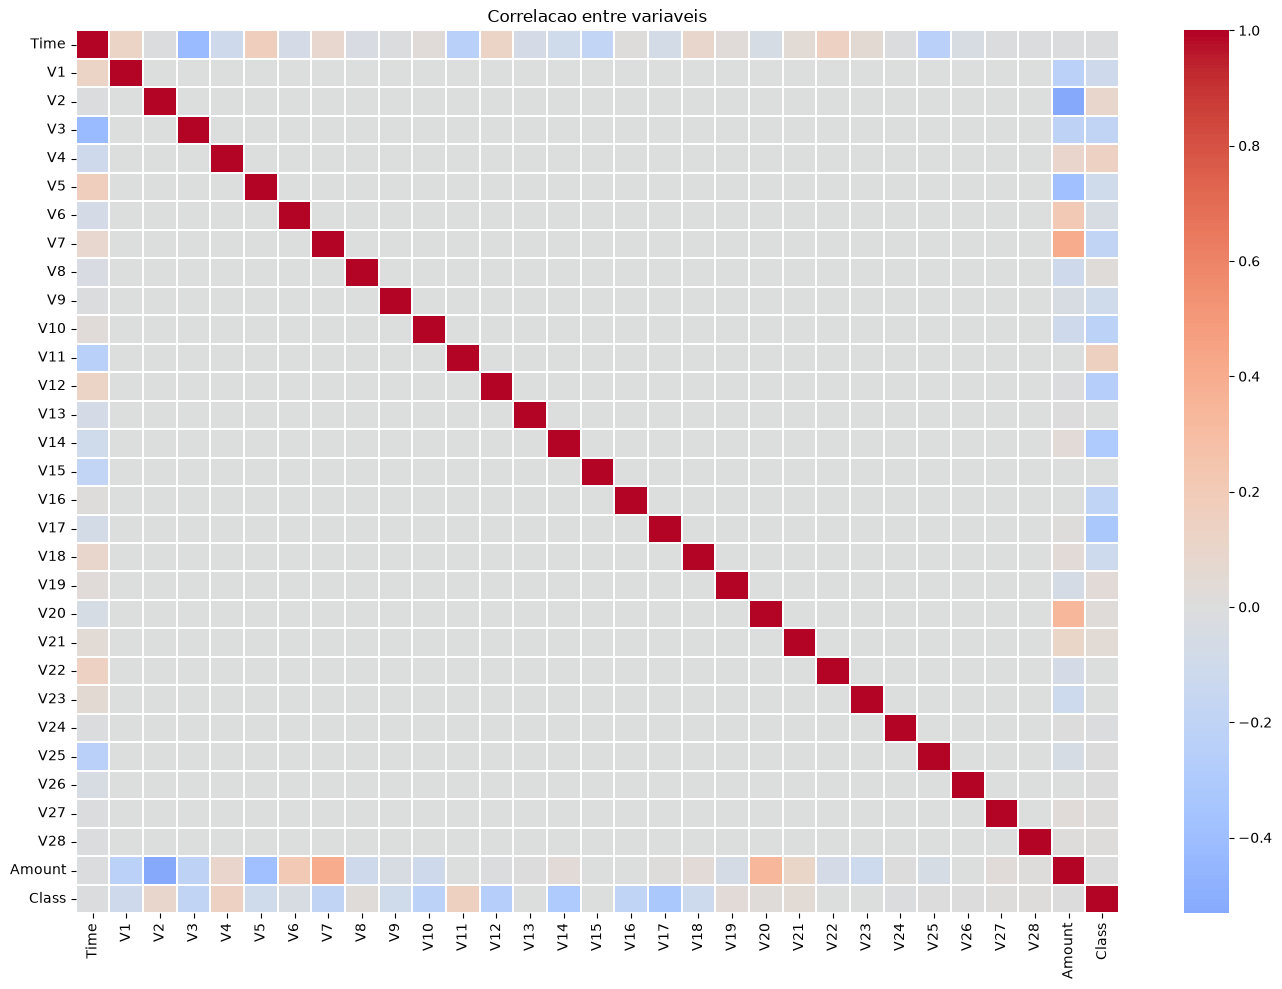


Features mais correlacionadas com fraude:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [4]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title('Correlacao entre variaveis')
plt.tight_layout()
plt.savefig('/workspaces/Top-Radar/grafico3.png', dpi=150)
plt.show()

print("\nFeatures mais correlacionadas com fraude:")
print(df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10))

              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00     56864
      Fraude       0.91      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



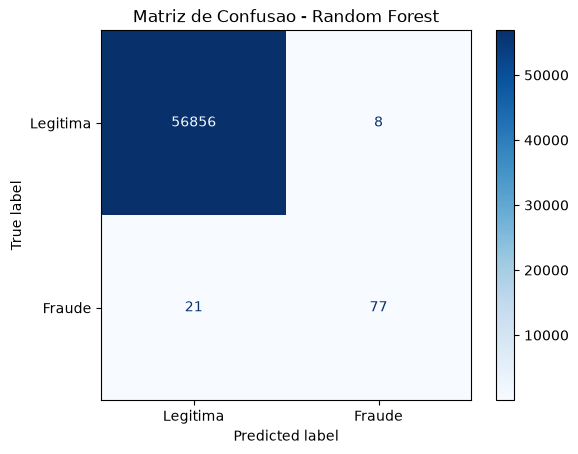

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Legitima', 'Fraude']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitima', 'Fraude'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusao - Random Forest')
plt.savefig('/workspaces/Top-Radar/grafico4.png', dpi=150)
plt.show()

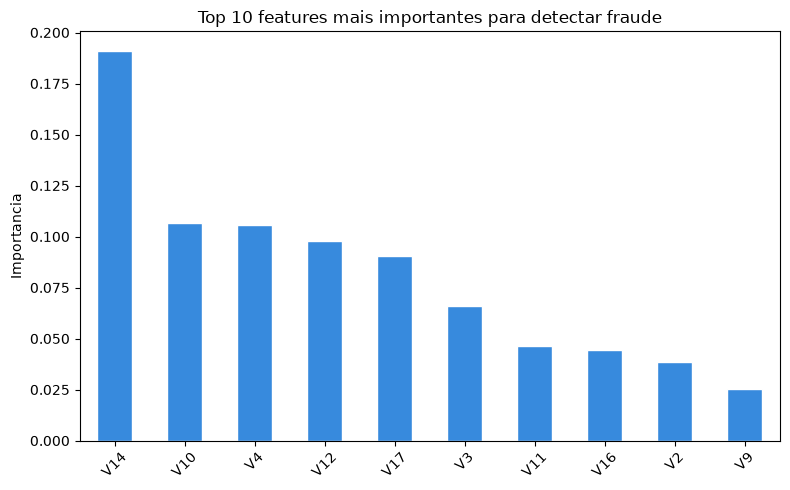

V14    0.191038
V10    0.106849
V4     0.105643
V12    0.097603
V17    0.090339
V3     0.065919
V11    0.046342
V16    0.044655
V2     0.038335
V9     0.025445
dtype: float64


In [6]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importancias.plot(kind='bar', color='#378ADD', edgecolor='white')
plt.title('Top 10 features mais importantes para detectar fraude')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/workspaces/Top-Radar/grafico5.png', dpi=150)
plt.show()

print(importancias)